In [ ]:
pip install transformers==4.41.2 accelerate==0.30.1 huggingface-hub==0.34.0 tokenizers==0.19.1

In [12]:
# =========================
# Import Libraries
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np
import re

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

In [11]:
# =========================
# Reproducibility
# =========================

import random
import numpy as np
import torch
from transformers import set_seed

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

In [14]:
# =========================
# Load Dataset
# =========================

train = pd.read_excel("toxic_labeled.xlsx")
test = pd.read_excel("toxic_no_label_evaluation.xlsx")

# Preview data
print(train.head())

                                                text  label
0  To everyone that became an eagle today. Congra...      0
1  राहुल गांधी की रैली में 95% लोग तो केवल ये देख...      1
2  देख लो ,ये अम्मा कांग्रेस की रजिस्टर्ड दुखियार...      1
3  We are straight but not blind best quote from ...      0
4  बोल तो ऐसे रहा है जैसे वो हल्दीघाटी का युद्ध ल...      1


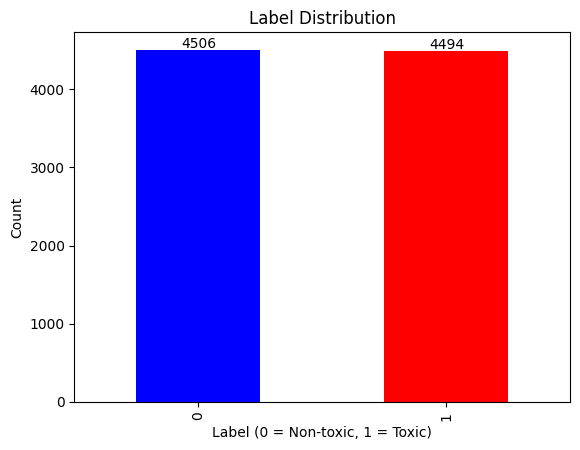

In [15]:
# =========================
# Exploratory Data Analysis
# =========================

# Check label distribution
counts = train["label"].value_counts()

counts.plot(kind="bar", color=["blue", "red"])

for i, v in enumerate(counts):
    plt.text(i, v + 20, str(v), ha='center')

plt.title("Label Distribution")
plt.xlabel("Label (0 = Non-toxic, 1 = Toxic)")
plt.ylabel("Count")
plt.show()

 The dataset is balanced, which helps prevent model bias.

In [16]:
# =========================
# Data Cleaning
# =========================

# Remove missing values to avoid invalid inputs
train = train.dropna(subset=["text"])
test = test.dropna(subset=["text"])

# Remove duplicates and empty text
test = test.drop_duplicates()
test = test[test["text"].str.strip() != ""]

In [17]:
# =========================
# Load Pretrained Model
# =========================

model_name = "textdetox/bert-multilingual-toxicity-classifier"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Device setup (CPU/GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [18]:
# =========================
# Tokenization
# =========================

def tokenize(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128
    )

# Tokenize text for BERT model
train_encodings = tokenize(train["text"].tolist())
test_encodings = tokenize(test["text"].tolist())

In [19]:
# =========================
# Custom Dataset Class
# =========================

class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.encodings["input_ids"])

In [20]:
# ==============================================
# Validation Split + Training + Evaluation
# ==============================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import pandas as pd
import torch
import numpy as np

# 🔹 1. Stratified Split
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train["text"].tolist(),
    train["label"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=train["label"].tolist()
)

print(f"Train size: {len(train_texts)} | Val size: {len(val_texts)}")
print(f"Train label dist: {pd.Series(train_labels).value_counts().to_dict()}")
print(f"Val label dist:   {pd.Series(val_labels).value_counts().to_dict()}")

# 🔹 2. Tokenization
train_encodings = tokenize(train_texts)
val_encodings = tokenize(val_texts)

# 🔹 3. Dataset
train_dataset = Dataset(train_encodings, train_labels)
val_dataset = Dataset(val_encodings, val_labels)

# 🔹 4. Training config
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    warmup_ratio=0.1,
    weight_decay=0.01,
    save_strategy="no",
    logging_steps=100,
)

# 🔹 5. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

# =========================
# 🔍 Zero-shot baseline
# =========================
model.eval()

zero_preds = trainer.predict(val_dataset)
zero_probs = torch.nn.functional.softmax(
    torch.tensor(zero_preds.predictions), dim=1
).numpy()

zero_roc = roc_auc_score(val_labels, zero_probs[:, 1])
print(f"\nZero-shot ROC-AUC: {zero_roc:.4f}")

model.train()

# 🔹 6. Train
print("\nTraining model...")
trainer.train()

# 🔹 7. Evaluate AFTER training
val_preds = trainer.predict(val_dataset)

probs = torch.nn.functional.softmax(
    torch.tensor(val_preds.predictions), dim=1
).numpy()

roc = roc_auc_score(val_labels, probs[:, 1])
print(f"\nValidation ROC-AUC: {roc:.4f}")

# =========================
# Final Summary + Report
# =========================
print("\n==============================")
print(f"Zero-shot ROC-AUC  : {zero_roc:.4f}")
print(f"Fine-tuned ROC-AUC : {roc:.4f}")
print(f"Improvement        : +{roc - zero_roc:.4f}")
print("==============================")

# 🔹 Classification Report
final_binary = np.argmax(probs, axis=1)

print("\nClassification Report:")
print(classification_report(val_labels, final_binary, target_names=["Non-toxic", "Toxic"]))

Train size: 7196 | Val size: 1800
Train label dist: {0: 3602, 1: 3594}
Val label dist:   {0: 901, 1: 899}


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



Zero-shot ROC-AUC: 0.9989

Training model...


Step,Training Loss
100,0.078813
200,0.163309
300,0.375967
400,0.303646
500,0.335186
600,0.312479
700,0.295023
800,0.253657
900,0.227173
1000,0.172070



Validation ROC-AUC: 0.9966

Zero-shot ROC-AUC  : 0.9989
Fine-tuned ROC-AUC : 0.9966
Improvement        : +-0.0023

Classification Report:
              precision    recall  f1-score   support

   Non-toxic       0.98      0.97      0.97       901
       Toxic       0.97      0.98      0.97       899

    accuracy                           0.97      1800
   macro avg       0.97      0.97      0.97      1800
weighted avg       0.97      0.97      0.97      1800



This metric evaluates how well the model distinguishes toxic vs non-toxic text.

In [21]:
# =========================
# Prediction on Test Data
# =========================

test_dataset = Dataset(test_encodings)

predictions = trainer.predict(test_dataset)

In [22]:
# =========================
# Convert Predictions to Labels
# =========================

probs = torch.nn.functional.softmax(
    torch.tensor(predictions.predictions), dim=1
).numpy()

labels = np.argmax(probs, axis=1)

test["label"] = labels

In [23]:
print(test.isnull().sum())
print(test["label"].unique())

text     0
label    0
dtype: int64
[1 0]


In [24]:
# =========================
# Save Final Submission File
# =========================

test.to_csv("no_label.csv", index=False)

In [25]:
# =========================
# Sample Predictions
# =========================

sample_texts = ["you are stupid", "this is amazing"]

enc = tokenizer(sample_texts, return_tensors="pt", truncation=True, padding=True)
enc = {k: v.to(device) for k, v in enc.items()}

outputs = model(**enc)

probs = torch.nn.functional.softmax(outputs.logits, dim=1)
preds = torch.argmax(probs, dim=1).tolist()

for t, p in zip(sample_texts, preds):
    print(f"{t} → {p}")

you are stupid → 1
this is amazing → 0


In [26]:
print("Pipeline completed successfully ✅")

Pipeline completed successfully ✅
